# Data Visualization Decision Guide for Data Analysts

**Goal:** Learn how to take practical business/data decisions from charts and graphs.

This notebook teaches:

1. How to choose the correct chart
2. How to read patterns from visualization
3. What decision can be taken from each chart
4. Common mistakes while interpreting charts
5. Practical Python examples using `pandas`, `numpy`, and `matplotlib`

> Think like a data analyst: **Chart → Pattern → Meaning → Decision → Action**

## 1. The Data Analyst Decision Framework

Before making any chart, ask:

### Step 1: What question am I answering?
Examples:
- Which product sells the most?
- Is revenue increasing or decreasing?
- Which region has high profit but low sales?
- Are discounts reducing profit?
- Are customers leaving after signup?

### Step 2: What type of data do I have?

| Data Type | Meaning | Example |
|---|---|---|
| Categorical | Groups/classes | Region, product, gender |
| Numerical | Measurable numbers | Sales, profit, age |
| Time series | Date/time based data | Daily sales, monthly revenue |
| Geographical | Location based data | Country, city, district |
| Text | Written words | Reviews, comments |

### Step 3: What decision type do I need?

| Decision Need | Best Chart Family |
|---|---|
| Compare categories | Bar chart, column chart |
| See trend over time | Line chart, area chart |
| See distribution | Histogram, boxplot, violin plot |
| See relationship | Scatter plot, bubble chart |
| See composition/share | Pie, donut, stacked bar, treemap |
| Find outliers | Boxplot, scatter plot |
| Find correlation | Heatmap, scatter plot |
| Find ranking | Horizontal bar, Pareto chart |
| Understand process drop-off | Funnel chart |
| Track stability | Control chart |
| Compare many variables | Pair plot, correlation matrix |

## 2. Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducible random numbers
np.random.seed(42)

# Make pandas output easier to read
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 3. Create a Practice Dataset

We will create a realistic business dataset containing:
- Date
- Region
- Product category
- Sales channel
- Units sold
- Price
- Revenue
- Cost
- Profit
- Discount
- Customer satisfaction
- Delivery days

This dataset is useful for practicing decision-making visualization.

In [2]:
n = 600

dates = pd.date_range("2025-01-01", periods=365, freq="D")
regions = ["Dhaka", "Chittagong", "Rajshahi", "Khulna", "Sylhet"]
products = ["Laptop", "Phone", "Headphone", "Monitor", "Keyboard"]
channels = ["Online", "Retail", "Distributor"]

df = pd.DataFrame({
    "date": np.random.choice(dates, n),
    "region": np.random.choice(regions, n, p=[0.35, 0.22, 0.15, 0.15, 0.13]),
    "product": np.random.choice(products, n, p=[0.18, 0.30, 0.22, 0.16, 0.14]),
    "channel": np.random.choice(channels, n, p=[0.45, 0.35, 0.20]),
    "units_sold": np.random.poisson(lam=8, size=n) + 1,
    "unit_price": np.random.normal(loc=250, scale=80, size=n).round(2),
    "discount_pct": np.random.choice([0, 5, 10, 15, 20, 25], n, p=[0.30, 0.20, 0.20, 0.15, 0.10, 0.05]),
    "customer_satisfaction": np.random.normal(loc=7.2, scale=1.1, size=n).round(1),
    "delivery_days": np.random.poisson(lam=4, size=n) + 1
})

# Clean unrealistic prices and satisfaction
df["unit_price"] = df["unit_price"].clip(lower=50)
df["customer_satisfaction"] = df["customer_satisfaction"].clip(lower=1, upper=10)

# Create revenue/cost/profit
df["gross_revenue"] = df["units_sold"] * df["unit_price"]
df["discount_amount"] = df["gross_revenue"] * df["discount_pct"] / 100
df["revenue"] = df["gross_revenue"] - df["discount_amount"]

cost_rate = np.random.normal(loc=0.62, scale=0.08, size=n)
df["cost"] = df["gross_revenue"] * cost_rate
df["profit"] = df["revenue"] - df["cost"]
df["profit_margin_pct"] = (df["profit"] / df["revenue"] * 100).round(2)

# Add a few missing values intentionally
missing_indices = np.random.choice(df.index, size=25, replace=False)
df.loc[missing_indices[:8], "customer_satisfaction"] = np.nan
df.loc[missing_indices[8:16], "delivery_days"] = np.nan
df.loc[missing_indices[16:], "discount_pct"] = np.nan

# Add month column
df["month"] = df["date"].dt.to_period("M").astype(str)

df.head()

,date,region,product,channel,units_sold,unit_price,discount_pct,customer_satisfaction,delivery_days,gross_revenue,discount_amount,revenue,cost,profit,profit_margin_pct,month
0,2025-04-13,Dhaka,Laptop,Retail,9,214.35,15.0,5.7,2.0,1929.15,289.3725,1639.7775,1350.621514,289.155986,17.63,2025-04
1,2025-12-15,Khulna,Headphone,Online,8,414.31,10.0,6.6,3.0,3314.48,331.4480,2983.0320,1933.705531,1049.326469,35.18,2025-12
2,2025-09-28,Rajshahi,Phone,Retail,11,185.00,15.0,7.8,6.0,2035.00,305.2500,1729.7500,1135.476865,594.273135,34.36,2025-09
3,2025-04-17,Dhaka,Laptop,Retail,13,418.42,5.0,6.1,5.0,5439.46,271.9730,5167.4870,3860.293059,1307.193941,25.30,2025-04
4,2025-03-13,Dhaka,Laptop,Distributor,10,252.79,15.0,9.0,4.0,2527.90,379.1850,2148.7150,1602.439693,546.275307,25.42,2025-03


## 4. First Look at the Data

Before visualization, always check:
- Number of rows and columns
- Missing values
- Data types
- Basic statistics

Decision reason: if the data quality is bad, the visualization can mislead you.

In [3]:
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (600, 16)


,date,region,product,channel,units_sold,unit_price,discount_pct,customer_satisfaction,delivery_days,gross_revenue,discount_amount,revenue,cost,profit,profit_margin_pct,month
0,2025-04-13,Dhaka,Laptop,Retail,9,214.35,15.0,5.7,2.0,1929.15,289.3725,1639.7775,1350.621514,289.155986,17.63,2025-04
1,2025-12-15,Khulna,Headphone,Online,8,414.31,10.0,6.6,3.0,3314.48,331.4480,2983.0320,1933.705531,1049.326469,35.18,2025-12
2,2025-09-28,Rajshahi,Phone,Retail,11,185.00,15.0,7.8,6.0,2035.00,305.2500,1729.7500,1135.476865,594.273135,34.36,2025-09
3,2025-04-17,Dhaka,Laptop,Retail,13,418.42,5.0,6.1,5.0,5439.46,271.9730,5167.4870,3860.293059,1307.193941,25.30,2025-04
4,2025-03-13,Dhaka,Laptop,Distributor,10,252.79,15.0,9.0,4.0,2527.90,379.1850,2148.7150,1602.439693,546.275307,25.42,2025-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   600 non-null    datetime64[ns]
 1   region                 600 non-null    object        
 2   product                600 non-null    object        
 3   channel                600 non-null    object        
 4   units_sold             600 non-null    int32         
 5   unit_price             600 non-null    float64       
 6   discount_pct           591 non-null    float64       
 7   customer_satisfaction  592 non-null    float64       
 8   delivery_days          592 non-null    float64       
 9   gross_revenue          600 non-null    float64       
 10  discount_amount        600 non-null    float64       
 11  revenue                600 non-null    float64       
 12  cost                   600 non-null    float64       
 13  profi

None

,date,region,product,channel,units_sold,unit_price,discount_pct,customer_satisfaction,delivery_days,gross_revenue,discount_amount,revenue,cost,profit,profit_margin_pct,month
count,600,600,600,600,600.000000,600.000000,591.000000,592.000000,592.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600
unique,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
top,NaN,Dhaka,Phone,Online,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08
freq,NaN,216,166,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61
mean,2025-07-03 21:28:48,NaN,NaN,NaN,8.870000,249.812133,8.130288,7.153041,4.996622,2226.392367,175.547363,2050.845003,1373.209946,677.635058,32.394167,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,2.000000,50.000000,0.000000,3.100000,1.000000,343.200000,0.000000,280.000000,194.118370,-40.380112,-3.320000,NaN
25%,2025-04-10 00:00:00,NaN,NaN,NaN,7.000000,194.030000,0.000000,6.400000,4.000000,1501.147500,0.000000,1349.268750,890.304005,366.330715,25.887500,NaN
50%,2025-07-03 12:00:00,NaN,NaN,NaN,9.000000,248.415000,5.000000,7.200000,5.000000,2076.240000,126.187000,1888.935500,1275.121135,594.666448,33.345000,NaN
75%,2025-09-27 06:00:00,NaN,NaN,NaN,11.000000,306.515000,15.000000,8.000000,6.000000,2851.375000,285.926500,2594.845500,1736.030794,921.192811,39.907500,NaN
max,2025-12-31 00:00:00,NaN,NaN,NaN,17.000000,472.400000,25.000000,10.000000,12.000000,5966.240000,946.140000,5966.240000,4338.067017,2855.471370,57.310000,NaN


In [4]:
# Missing value check
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

discount_pct             9
customer_satisfaction    8
delivery_days            8
dtype: int64

# Chart Selection Map

Use this as your quick guide.

| Question | Chart |
|---|---|
| Which category is highest/lowest? | Bar chart |
| Which item ranks first to last? | Horizontal bar chart |
| How does a metric change over time? | Line chart |
| How much does each category contribute to total? | Pie/donut/stacked bar |
| How is data distributed? | Histogram |
| Are there outliers? | Boxplot |
| Are two numeric variables related? | Scatter plot |
| Which variables move together? | Correlation heatmap |
| Which few categories create most of the result? | Pareto chart |
| Where is the process losing people/items? | Funnel chart |
| Is a process stable or abnormal? | Control chart |

# 5. Bar Chart / Column Chart

## Purpose
A bar chart compares values across categories.

## Best for
- Revenue by product
- Profit by region
- Number of students by department
- Sales by channel

## How to read
- Tallest bar = highest value
- Shortest bar = lowest value
- Large gap between bars = strong difference
- Similar bars = no major difference

## Decision from this chart
- Focus marketing on high-performing category
- Investigate low-performing category
- Allocate budget/resources based on category performance

## Warning
Do not use too many categories. If categories are many, use horizontal bar chart.

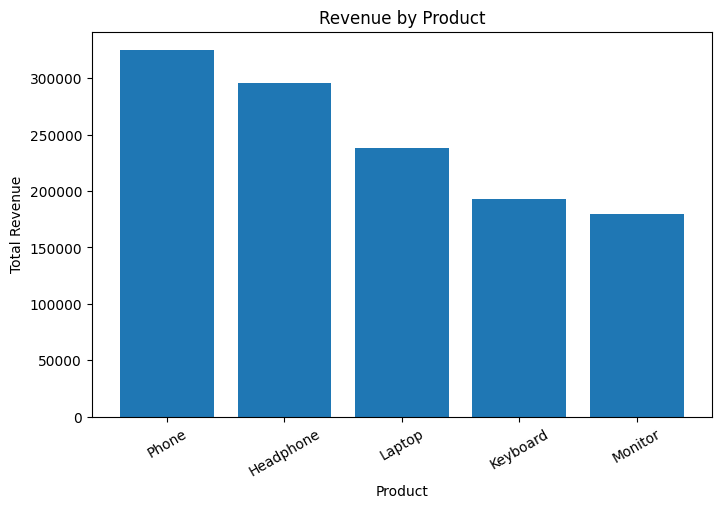

product
Phone        324885.4660
Headphone    295335.0780
Laptop       238404.2155
Keyboard     192479.7025
Monitor      179402.5400
Name: revenue, dtype: float64

In [5]:
product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(product_revenue.index, product_revenue.values)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

product_revenue

### Analyst Interpretation

Look at the highest revenue product. That product may deserve:
- More inventory
- More marketing budget
- Better placement on website/store

But do not decide only from revenue. Also check profit margin.

# 6. Horizontal Bar Chart

## Purpose
A horizontal bar chart is best when category names are long or when ranking is important.

## Best for
- Top 10 products
- Top customers
- Top cities
- Top causes of complaints

## Decision from this chart
- Prioritize top-ranked categories
- Find weak areas at the bottom
- Focus on the top 20% that creates most results

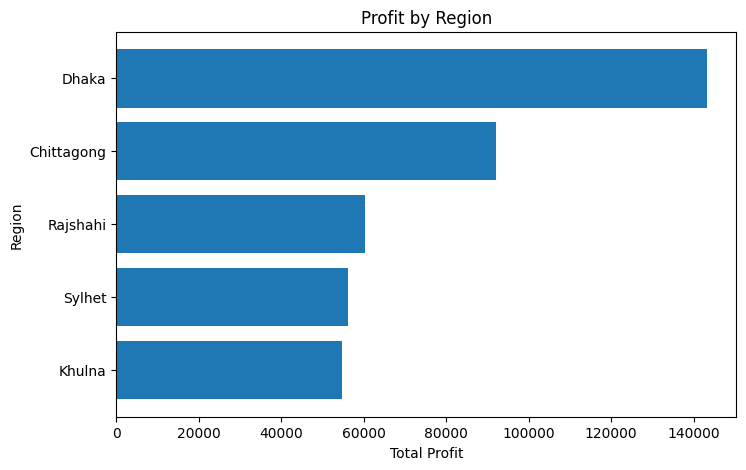

region
Dhaka         143201.225709
Chittagong     92162.653683
Rajshahi       60370.721168
Sylhet         56180.448893
Khulna         54665.985108
Name: profit, dtype: float64

In [6]:
region_profit = df.groupby("region")["profit"].sum().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(region_profit.index, region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")
plt.show()

region_profit.sort_values(ascending=False)

# 7. Grouped Bar Chart

## Purpose
A grouped bar chart compares categories across another category.

## Best for
- Product revenue by channel
- Gender performance by department
- Region-wise product sales
- Online vs offline performance

## How to read
- Compare bars within the same group
- Find which segment performs better for each category

## Decision from this chart
- Choose the best channel for each product
- Identify segment-specific strengths
- Avoid one-size-fits-all decisions

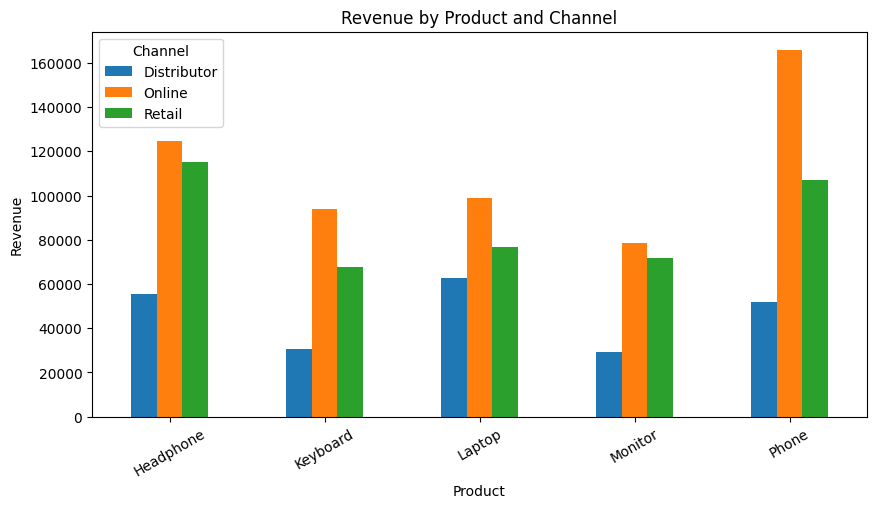

channel,Distributor,Online,Retail
product,,,
Headphone,55559.9680,124467.2090,115307.9010
Keyboard,30727.6865,93882.3785,67869.6375
Laptop,62830.8870,98945.7575,76627.5710
Monitor,29266.5615,78438.8000,71697.1785
Phone,51882.9935,165800.9200,107201.5525


In [7]:
grouped = df.groupby(["product", "channel"])["revenue"].sum().unstack()

grouped.plot(kind="bar", figsize=(10, 5))
plt.title("Revenue by Product and Channel")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.legend(title="Channel")
plt.show()

grouped

### Analyst Interpretation

If one product performs better online but another performs better in retail, you should not use the same sales strategy for all products.

# 8. Stacked Bar Chart

## Purpose
A stacked bar chart shows total value and contribution of sub-categories.

## Best for
- Revenue by region split by channel
- Sales by product split by gender
- Expenses by department split by type

## How to read
- Full bar height = total
- Each segment = contribution to total

## Decision from this chart
- Understand both total performance and internal mix
- See whether a region depends too much on one channel
- Balance risk by diversifying channels

## Warning
Stacked bars are not ideal for exact comparison of middle segments.

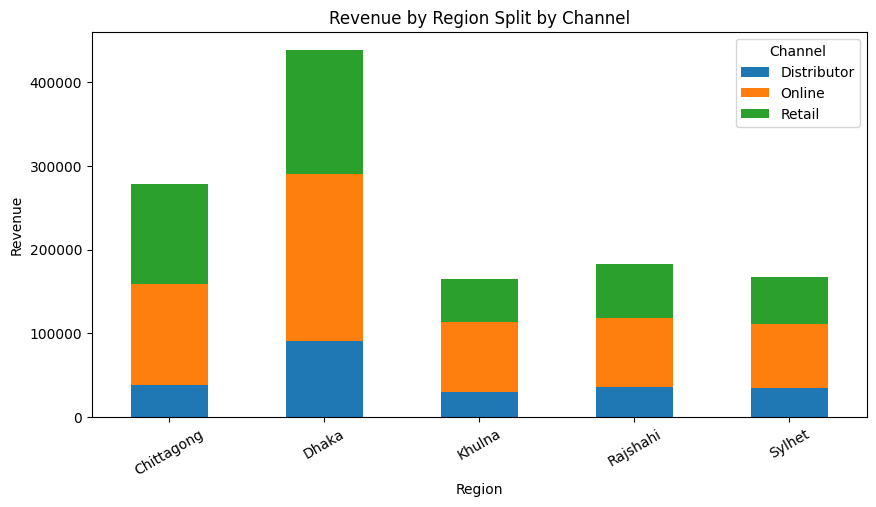

channel,Distributor,Online,Retail
region,,,
Chittagong,37929.9490,120936.4930,119421.2360
Dhaka,91462.6825,198346.1595,148080.0060
Khulna,30202.6310,83008.9265,51624.3720
Rajshahi,35533.7065,82750.9255,64343.6320
Sylhet,35139.1275,76492.5605,55234.5945


In [8]:
stacked = df.groupby(["region", "channel"])["revenue"].sum().unstack()

stacked.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Revenue by Region Split by Channel")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.legend(title="Channel")
plt.show()

stacked

# 9. 100% Stacked Bar Chart

## Purpose
A 100% stacked bar chart shows percentage composition, not absolute value.

## Best for
- Channel share by region
- Product mix by market
- Customer type percentage by city

## How to read
- Every bar equals 100%
- Segment size shows share/percentage

## Decision from this chart
- Compare structure/mix across groups
- Identify dependency on one segment
- Choose where diversification is needed

## Warning
It hides absolute volume. A small region and large region both look equal in height.

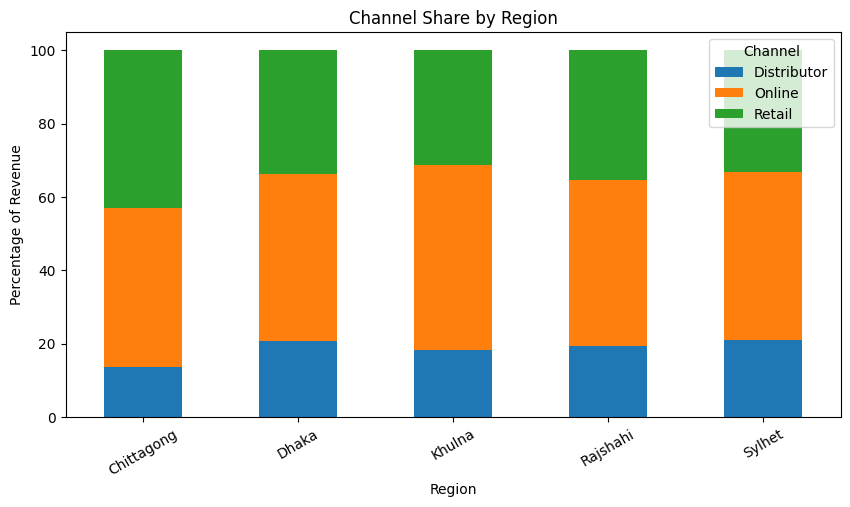

channel,Distributor,Online,Retail
region,,,
Chittagong,13.63,43.46,42.91
Dhaka,20.89,45.30,33.82
Khulna,18.32,50.36,31.32
Rajshahi,19.46,45.31,35.23
Sylhet,21.06,45.84,33.10


In [9]:
share = stacked.div(stacked.sum(axis=1), axis=0) * 100

share.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Channel Share by Region")
plt.xlabel("Region")
plt.ylabel("Percentage of Revenue")
plt.xticks(rotation=30)
plt.legend(title="Channel")
plt.show()

share.round(2)

# 10. Line Chart

## Purpose
A line chart shows trend over time.

## Best for
- Daily sales
- Monthly revenue
- Website visitors over time
- Temperature over time

## How to read
- Upward line = growth
- Downward line = decline
- Sharp spike = unusual event
- Repeated pattern = seasonality

## Decision from this chart
- Increase stock before expected high-demand periods
- Investigate sudden drops
- Track whether strategy is working after launch

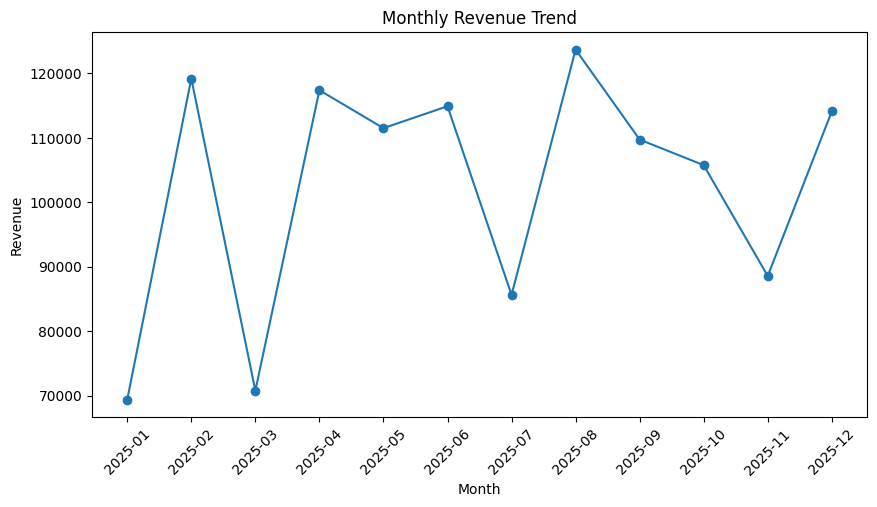

month
2025-01     69383.6110
2025-02    119181.1055
2025-03     70763.1870
2025-04    117374.5080
2025-05    111488.7990
2025-06    114887.2030
2025-07     85627.4775
2025-08    123679.0520
2025-09    109717.3175
2025-10    105746.2770
2025-11     88562.2815
2025-12    114096.1830
Name: revenue, dtype: float64

In [10]:
monthly_revenue = df.groupby("month")["revenue"].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

monthly_revenue

### Analyst Interpretation

Do not judge only one month. Look at the overall trend:
- Is it consistently increasing?
- Is there a sudden drop?
- Is the change seasonal or caused by a business event?

# 11. Rolling Average Line Chart

## Purpose
A rolling average smooths short-term noise and shows the real trend.

## Best for
- Daily revenue
- Stock price
- Website traffic
- App usage

## How to read
- Raw line = daily ups and downs
- Rolling average = smoother trend

## Decision from this chart
- Avoid overreacting to one bad day
- Detect real long-term changes

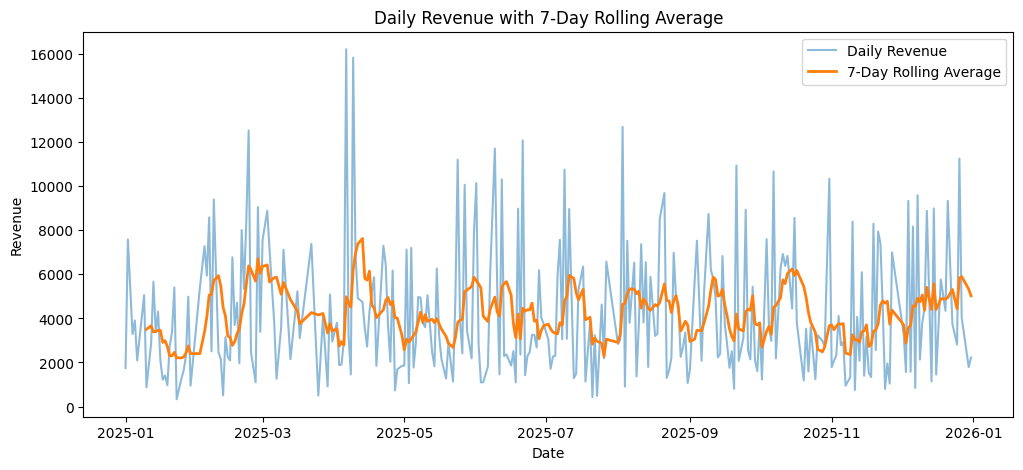

In [11]:
daily_revenue = df.groupby("date")["revenue"].sum().sort_index()
rolling_7 = daily_revenue.rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue.index, daily_revenue.values, alpha=0.5, label="Daily Revenue")
plt.plot(rolling_7.index, rolling_7.values, linewidth=2, label="7-Day Rolling Average")
plt.title("Daily Revenue with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

# 12. Area Chart

## Purpose
An area chart shows volume over time. It is like a line chart but emphasizes magnitude.

## Best for
- Cumulative sales
- Total users over time
- Total revenue trend
- Resource usage over time

## Decision from this chart
- See whether total volume is growing
- Identify periods of strong accumulation
- Understand contribution over time

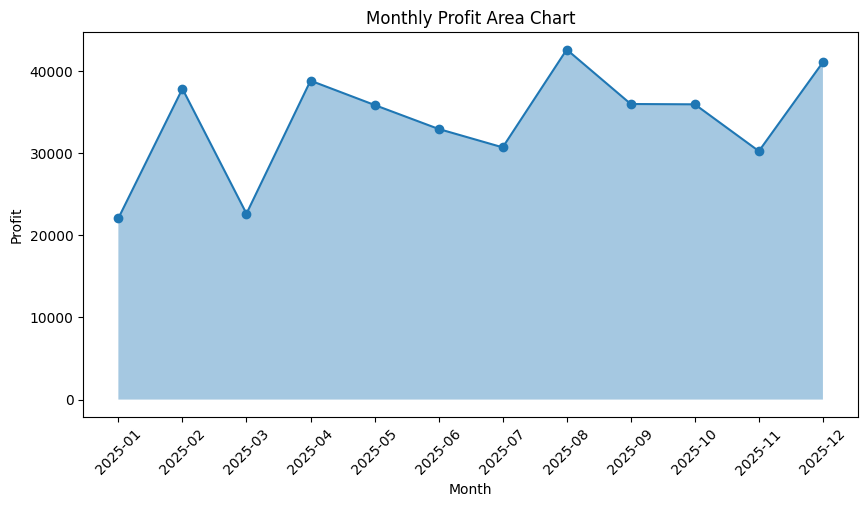

In [12]:
monthly_profit = df.groupby("month")["profit"].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_profit.index, monthly_profit.values, alpha=0.4)
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")
plt.title("Monthly Profit Area Chart")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

# 13. Histogram

## Purpose
A histogram shows the distribution of one numerical variable.

## Best for
- Age distribution
- Salary distribution
- Delivery time distribution
- Exam marks distribution

## How to read
- Tall bars = common value range
- Right tail = few very high values
- Left tail = few very low values
- Multiple peaks = possible different customer groups

## Decision from this chart
- Set realistic targets
- Detect skewed data
- Identify normal vs abnormal values
- Choose proper pricing or service-level policy

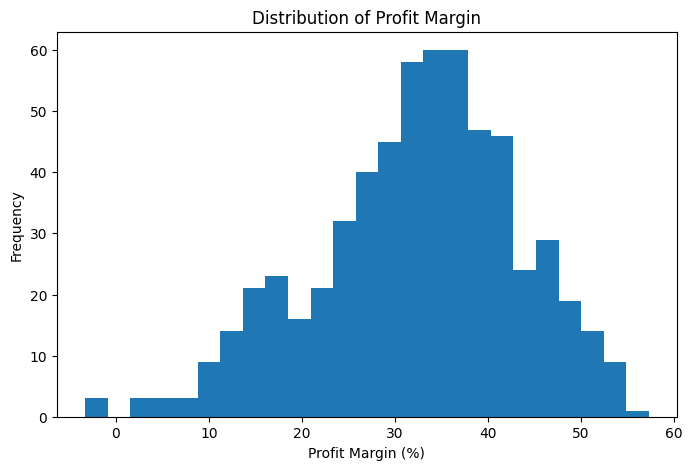

count    600.000000
mean      32.394167
std       10.849121
min       -3.320000
25%       25.887500
50%       33.345000
75%       39.907500
max       57.310000
Name: profit_margin_pct, dtype: float64

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["profit_margin_pct"].dropna(), bins=25)
plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.show()

df["profit_margin_pct"].describe()

### Analyst Interpretation

If most profit margins are low, the business may need:
- Lower cost
- Better pricing
- Reduced discount
- More profitable product mix

# 14. Boxplot

## Purpose
A boxplot summarizes distribution and shows outliers.

## Best for
- Profit by product
- Delivery time by region
- Salary by department
- Marks by section

## How to read
- Middle line = median
- Box = middle 50% of data
- Whiskers = normal range
- Points outside = possible outliers

## Decision from this chart
- Detect unstable product/region performance
- Find unusually high or low values
- Investigate outliers before removing them

C:\Users\PL\AppData\Local\Temp\ipykernel_21912\713436938.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=products_order)


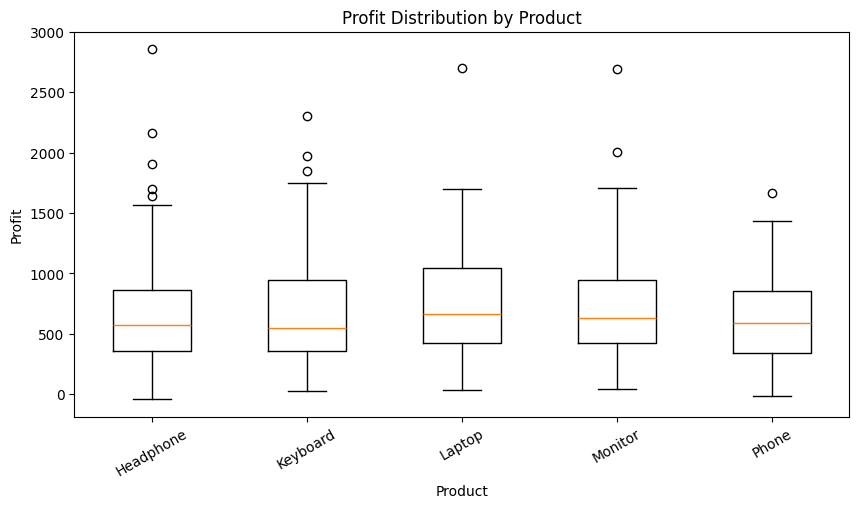

In [14]:
products_order = sorted(df["product"].unique())
data_for_box = [df.loc[df["product"] == p, "profit"].dropna() for p in products_order]

plt.figure(figsize=(10, 5))
plt.boxplot(data_for_box, labels=products_order)
plt.title("Profit Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=30)
plt.show()

# 15. Violin Plot

## Purpose
A violin plot shows distribution shape for different categories.

## Best for
- Comparing full distribution
- Seeing whether data is concentrated or spread
- Detecting multiple peaks in groups

## How to read
- Wider area = more data in that range
- Narrow area = fewer data points
- Different shapes = different customer/product behavior

## Decision from this chart
- Identify which category has stable or unstable performance
- Detect whether averages hide hidden groups

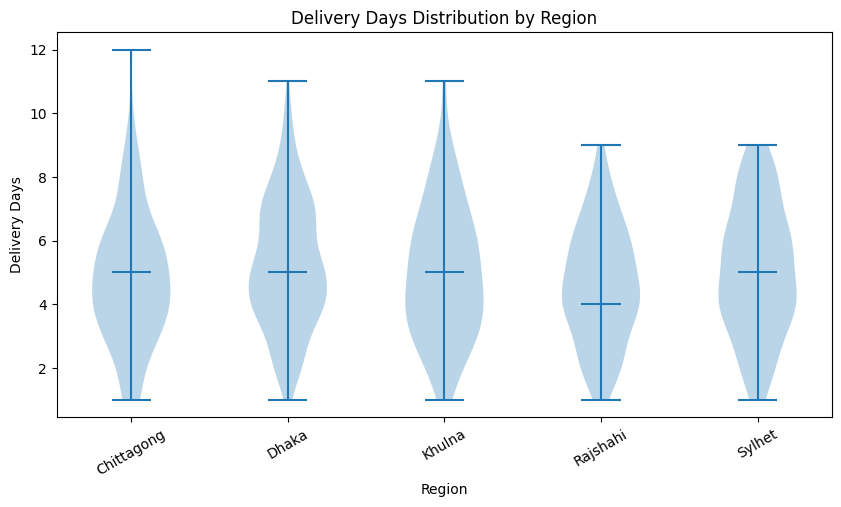

In [15]:
data_for_violin = [df.loc[df["region"] == r, "delivery_days"].dropna() for r in sorted(df["region"].unique())]

plt.figure(figsize=(10, 5))
plt.violinplot(data_for_violin, showmedians=True)
plt.xticks(range(1, len(sorted(df["region"].unique())) + 1), sorted(df["region"].unique()), rotation=30)
plt.title("Delivery Days Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Delivery Days")
plt.show()

# 16. Scatter Plot

## Purpose
A scatter plot shows the relationship between two numerical variables.

## Best for
- Discount vs profit
- Price vs demand
- Study hours vs marks
- Ad spend vs sales

## How to read
- Upward pattern = positive relationship
- Downward pattern = negative relationship
- No pattern = weak/no relationship
- Isolated points = outliers

## Decision from this chart
- Decide whether one variable may influence another
- Detect risky pricing or discount behavior
- Find unusual observations that need investigation

## Warning
Correlation does not always mean causation.

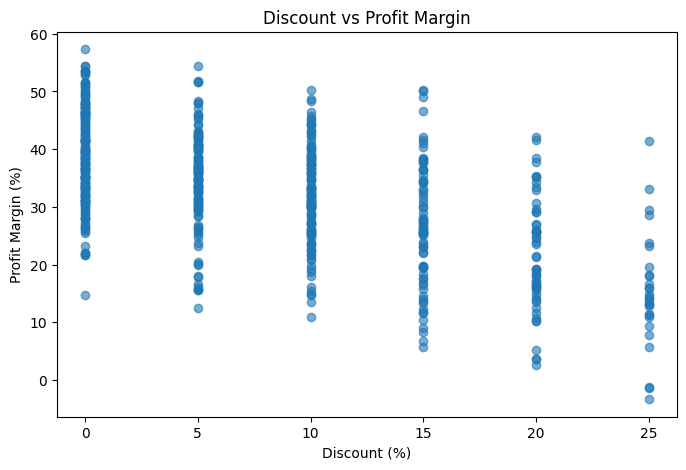

,discount_pct,profit_margin_pct
discount_pct,1.000000,-0.596181
profit_margin_pct,-0.596181,1.000000


In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["discount_pct"], df["profit_margin_pct"], alpha=0.6)
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.show()

df[["discount_pct", "profit_margin_pct"]].corr()

### Analyst Interpretation

If higher discount is linked with lower profit margin, decision may be:
- Reduce unnecessary discount
- Apply discount only to high-margin products
- Test discount impact using A/B testing

# 17. Bubble Chart

## Purpose
A bubble chart adds a third variable using bubble size.

## Best for
- Revenue vs profit, bubble size = units sold
- Price vs rating, bubble size = number of reviews
- Ad spend vs sales, bubble size = market size

## Decision from this chart
- Find high revenue but low profit groups
- Find small but highly profitable opportunities
- Prioritize segments with both size and profitability

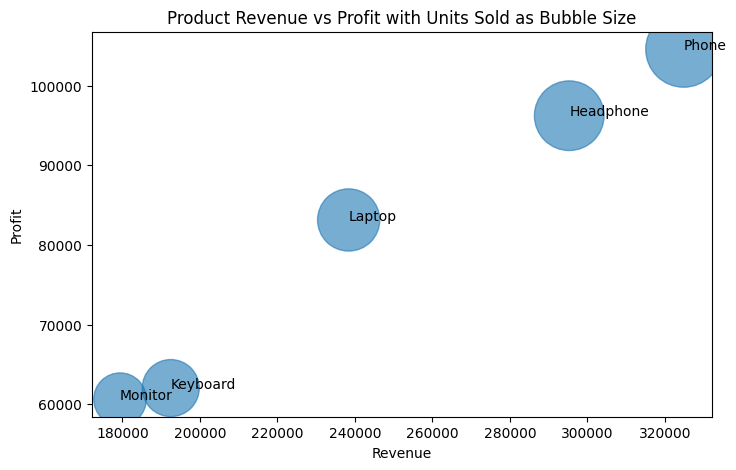

,product,revenue,profit,units
0,Headphone,295335.0780,96213.464090,1258
1,Keyboard,192479.7025,62040.136140,844
2,Laptop,238404.2155,83131.992341,1004
3,Monitor,179402.5400,60641.383219,719
4,Phone,324885.4660,104554.058772,1497


In [17]:
summary = df.groupby("product").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    units=("units_sold", "sum")
).reset_index()

plt.figure(figsize=(8, 5))
plt.scatter(summary["revenue"], summary["profit"], s=summary["units"]*2, alpha=0.6)

for i, row in summary.iterrows():
    plt.text(row["revenue"], row["profit"], row["product"])

plt.title("Product Revenue vs Profit with Units Sold as Bubble Size")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.show()

summary

# 18. Correlation Heatmap

## Purpose
A correlation heatmap shows how numerical variables move together.

## Best for
- Feature relationship in machine learning
- Business metric dependency
- Detecting multicollinearity
- Understanding drivers of revenue/profit

## How to read
- Correlation close to +1 = strong positive relationship
- Correlation close to -1 = strong negative relationship
- Correlation close to 0 = weak linear relationship

## Decision from this chart
- Find possible drivers of target variable
- Remove duplicate features in ML models
- Decide which variables need deeper analysis

## Warning
Correlation only captures linear relationship. It does not prove causation.

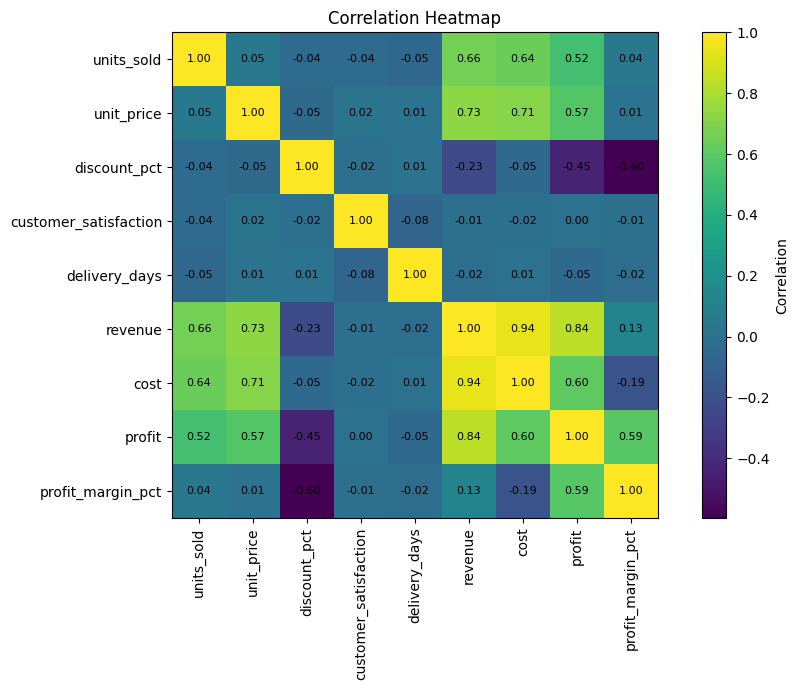

,units_sold,unit_price,discount_pct,customer_satisfaction,delivery_days,revenue,cost,profit,profit_margin_pct
units_sold,1.000000,0.051220,-0.035917,-0.037591,-0.054607,0.663746,0.643992,0.524407,0.040596
unit_price,0.051220,1.000000,-0.046518,0.018319,0.013982,0.727716,0.707702,0.572357,0.013655
discount_pct,-0.035917,-0.046518,1.000000,-0.016201,0.010633,-0.226616,-0.048604,-0.446270,-0.596181
customer_satisfaction,-0.037591,0.018319,-0.016201,1.000000,-0.078377,-0.009802,-0.015780,0.002152,-0.005770
delivery_days,-0.054607,0.013982,0.010633,-0.078377,1.000000,-0.019516,0.005036,-0.053204,-0.024235
revenue,0.663746,0.727716,-0.226616,-0.009802,-0.019516,1.000000,0.938704,0.839741,0.125796
cost,0.643992,0.707702,-0.048604,-0.015780,0.005036,0.938704,1.000000,0.601089,-0.187825
profit,0.524407,0.572357,-0.446270,0.002152,-0.053204,0.839741,0.601089,1.000000,0.587487
profit_margin_pct,0.040596,0.013655,-0.596181,-0.005770,-0.024235,0.125796,-0.187825,0.587487,1.000000


In [18]:
numeric_cols = [
    "units_sold", "unit_price", "discount_pct", "customer_satisfaction",
    "delivery_days", "revenue", "cost", "profit", "profit_margin_pct"
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

corr

# 19. Pair Plot / Scatter Matrix

## Purpose
A pair plot shows relationships among multiple numerical variables.

## Best for
- Early EDA
- Machine learning feature exploration
- Finding clusters and relationships

## Decision from this chart
- Select useful features
- Detect non-linear patterns
- Detect outliers across multiple dimensions

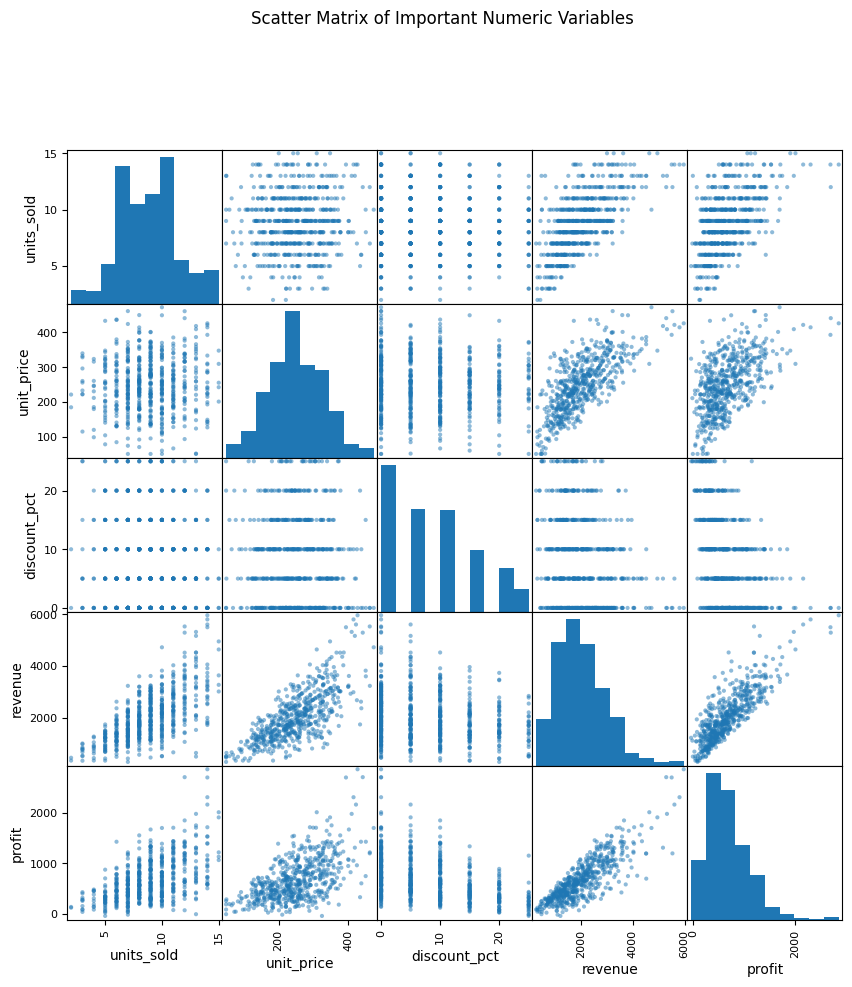

In [19]:
from pandas.plotting import scatter_matrix

sample_numeric = df[["units_sold", "unit_price", "discount_pct", "revenue", "profit"]].dropna()

scatter_matrix(sample_numeric, figsize=(10, 10), diagonal="hist", alpha=0.5)
plt.suptitle("Scatter Matrix of Important Numeric Variables", y=1.02)
plt.show()

# 20. Pie Chart

## Purpose
A pie chart shows part-to-whole composition.

## Best for
- Market share
- Budget share
- Revenue contribution by few categories

## How to read
- Biggest slice = biggest share
- Very small slices = minor contribution

## Decision from this chart
- Identify dominant category
- Understand composition of a total
- Communicate simple share to non-technical audience

## Warning
Use pie chart only when:
- Categories are few, usually 2 to 5
- Values add up to a meaningful total
- Exact ranking is not the main goal

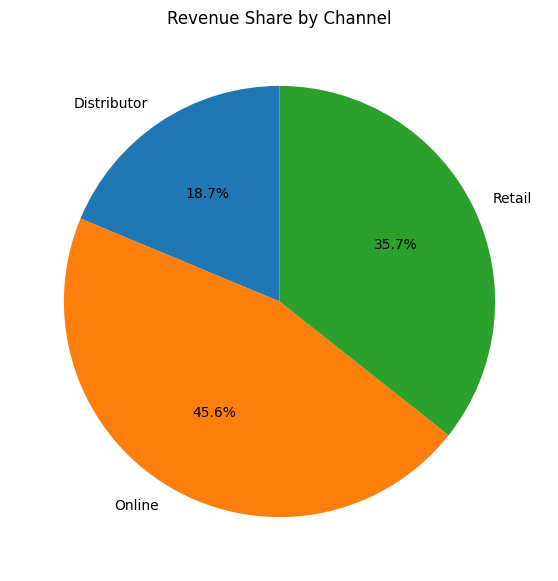

channel
Distributor    230268.0965
Online         561535.0650
Retail         438703.8405
Name: revenue, dtype: float64

In [20]:
channel_share = df.groupby("channel")["revenue"].sum()

plt.figure(figsize=(7, 7))
plt.pie(channel_share.values, labels=channel_share.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share by Channel")
plt.show()

channel_share

# 21. Donut Chart

## Purpose
A donut chart is a pie chart with a hole in the middle.

## Best for
- Simple share display
- Dashboard cards
- Presentations

## Decision from this chart
Same as pie chart, but visually cleaner for dashboards.

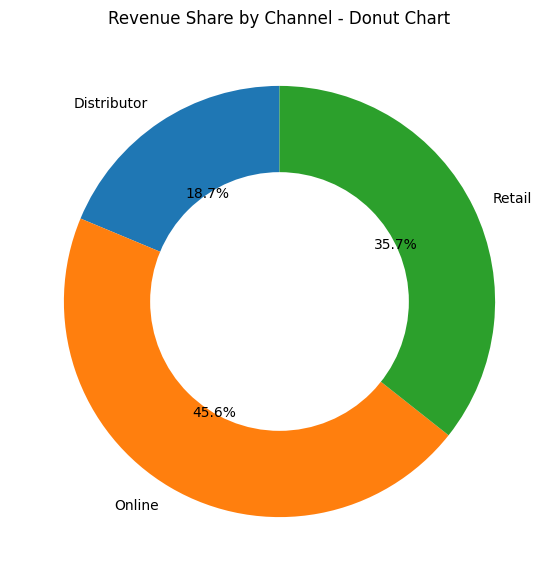

In [21]:
plt.figure(figsize=(7, 7))
plt.pie(channel_share.values, labels=channel_share.index, autopct="%1.1f%%", startangle=90)
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Revenue Share by Channel - Donut Chart")
plt.show()

# 22. Pareto Chart

## Purpose
A Pareto chart shows which categories contribute most to a total.

It follows the idea: **a small number of categories often create most of the result.**

## Best for
- Top products causing most sales
- Top problems causing most complaints
- Top customers creating most revenue
- Top reasons causing most defects

## How to read
- Bars = category value
- Line = cumulative percentage
- Check which categories reach 80%

## Decision from this chart
- Focus on the few important categories first
- Prioritize actions with maximum impact

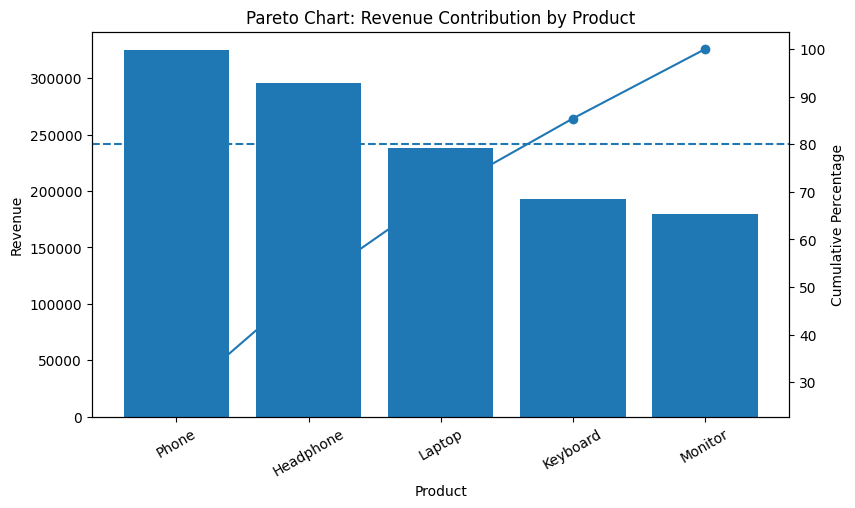

,revenue,cumulative_pct
product,,
Phone,324885.4660,26.40
Headphone,295335.0780,50.40
Laptop,238404.2155,69.78
Keyboard,192479.7025,85.42
Monitor,179402.5400,100.00


In [22]:
pareto = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
cum_pct = pareto.cumsum() / pareto.sum() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(pareto.index, pareto.values)
ax1.set_xlabel("Product")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(pareto.index, cum_pct.values, marker="o")
ax2.set_ylabel("Cumulative Percentage")
ax2.axhline(80, linestyle="--")

plt.title("Pareto Chart: Revenue Contribution by Product")
plt.show()

pd.DataFrame({"revenue": pareto, "cumulative_pct": cum_pct.round(2)})

# 23. Waterfall Chart

## Purpose
A waterfall chart shows how positive and negative changes lead from a starting value to an ending value.

## Best for
- Revenue to profit explanation
- Budget change
- Month-over-month profit bridge
- Cost breakdown

## How to read
- Start value
- Add positive changes
- Subtract negative changes
- End value

## Decision from this chart
- Find what increased or reduced final result
- Explain profit changes to managers
- Identify which cost needs control

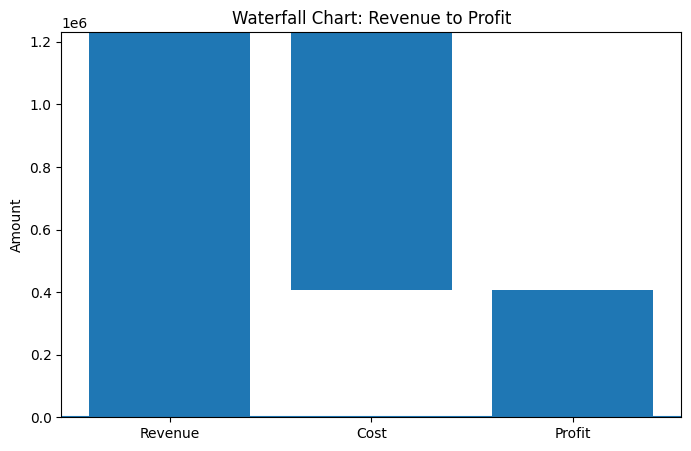

,item,value
0,Revenue,1.230507e+06
1,Cost,-8.239260e+05
2,Profit,4.065810e+05


In [23]:
# Example: Revenue to Profit Bridge
revenue_total = df["revenue"].sum()
cost_total = -df["cost"].sum()
profit_total = df["profit"].sum()

labels = ["Revenue", "Cost", "Profit"]
values = [revenue_total, cost_total, profit_total]

# Waterfall positions
starts = [0, revenue_total, 0]
heights = [revenue_total, cost_total, profit_total]

plt.figure(figsize=(8, 5))
plt.bar(labels, heights, bottom=starts)
plt.axhline(0)
plt.title("Waterfall Chart: Revenue to Profit")
plt.ylabel("Amount")
plt.show()

pd.DataFrame({"item": labels, "value": values})

# 24. Funnel Chart

## Purpose
A funnel chart shows step-by-step drop-off in a process.

## Best for
- Sales funnel
- Recruitment process
- Website conversion
- App onboarding

## How to read
- Each stage should reduce gradually
- Big drop between two stages = problem area

## Decision from this chart
- Improve the stage with biggest drop
- Find where customers/users leave
- Optimize conversion process

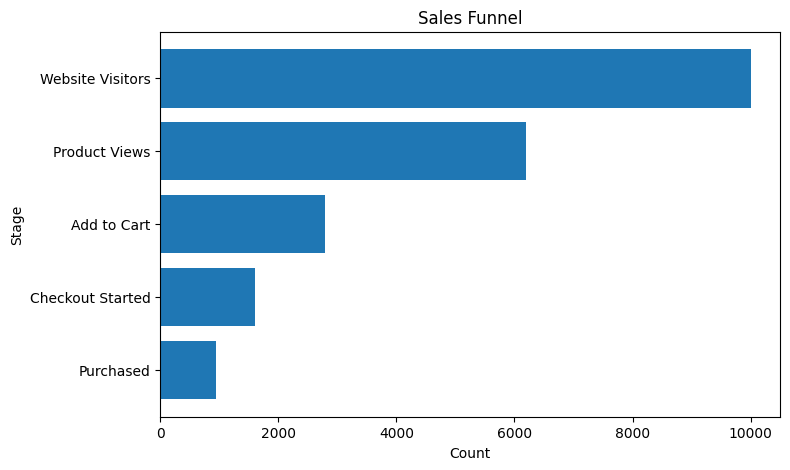

,stage,count,conversion_from_previous_pct
0,Website Visitors,10000,NaN
1,Product Views,6200,62.00
2,Add to Cart,2800,45.16
3,Checkout Started,1600,57.14
4,Purchased,950,59.38


In [24]:
funnel = pd.DataFrame({
    "stage": ["Website Visitors", "Product Views", "Add to Cart", "Checkout Started", "Purchased"],
    "count": [10000, 6200, 2800, 1600, 950]
})

plt.figure(figsize=(8, 5))
plt.barh(funnel["stage"], funnel["count"])
plt.gca().invert_yaxis()
plt.title("Sales Funnel")
plt.xlabel("Count")
plt.ylabel("Stage")
plt.show()

funnel["conversion_from_previous_pct"] = funnel["count"].pct_change().add(1).mul(100).round(2)
funnel

### Analyst Interpretation

The biggest drop tells you where to act first.  
Example:
- Product Views → Add to Cart drop: improve pricing, product photos, reviews, product description.
- Checkout Started → Purchased drop: improve payment, delivery cost, trust, coupon errors.

# 25. Pivot Heatmap

## Purpose
A pivot heatmap shows intensity across two categories.

## Best for
- Region × product revenue
- Day × hour website traffic
- Department × skill score
- Customer segment × product interest

## How to read
- Higher value cells show strong areas
- Lower value cells show weak areas
- Patterns reveal combinations that matter

## Decision from this chart
- Decide which product to push in which region
- Find location-specific opportunities
- Identify weak combinations needing attention

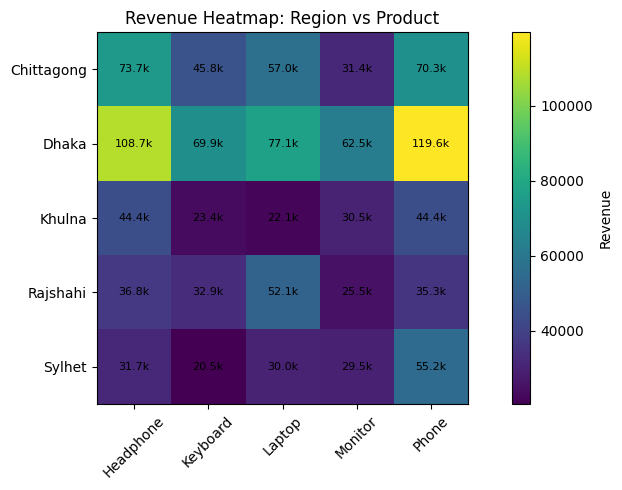

product,Headphone,Keyboard,Laptop,Monitor,Phone
region,,,,,
Chittagong,73709.3600,45819.4665,57006.4070,31405.0695,70347.3750
Dhaka,108716.2255,69878.8135,77117.7290,62535.7655,119640.3145
Khulna,44430.9615,23404.7215,22137.7840,30484.7035,44377.7590
Rajshahi,36774.8320,32891.4510,52117.8575,25519.7395,35324.3840
Sylhet,31703.6990,20485.2500,30024.4380,29457.2620,55195.6335


In [25]:
pivot = df.pivot_table(
    index="region",
    columns="product",
    values="revenue",
    aggfunc="sum"
)

plt.figure(figsize=(9, 5))
plt.imshow(pivot)
plt.colorbar(label="Revenue")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Revenue Heatmap: Region vs Product")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f"{pivot.iloc[i, j]/1000:.1f}k", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

pivot

# 26. Calendar / Day Pattern Heatmap

## Purpose
This chart shows patterns by day of week and month.

## Best for
- Sales by weekday
- Traffic by weekday
- Demand seasonality
- Attendance patterns

## Decision from this chart
- Plan staff schedule
- Plan promotions on weak days
- Increase stock before strong days

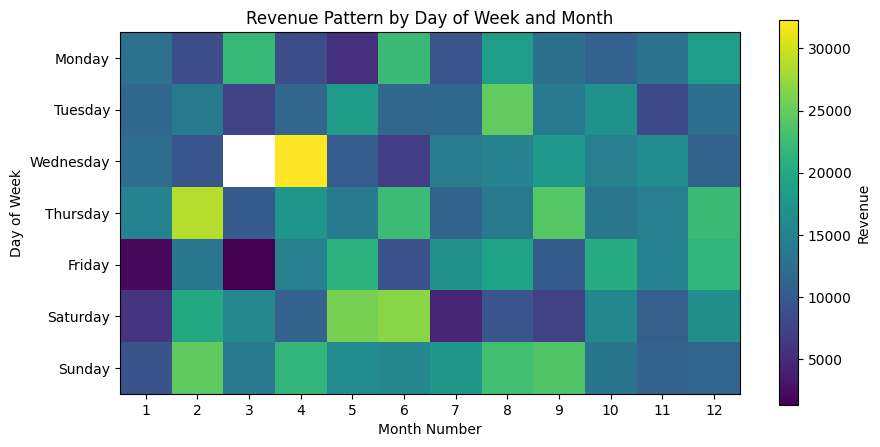

month_num,1,2,3,4,5,6,7,8,9,10,11,12
day_name,,,,,,,,,,,,
Monday,12779.3195,8635.4600,22050.2480,8530.4510,5452.9900,22427.4870,9477.0290,18546.9955,12679.6250,10991.9200,13043.2000,18578.0240
Tuesday,11736.8910,14139.0245,7625.8275,11474.2445,18322.9560,11552.0615,11586.2470,24792.0410,14086.7790,17182.2090,8155.9925,12411.8165
Wednesday,12407.3565,9508.9100,NaN,32254.4805,10251.8140,6920.4765,14282.4875,15027.8030,17804.2190,14750.7010,16190.7945,11156.7850
Thursday,15063.3990,28792.6170,10042.5715,17667.9490,14204.8620,22531.4265,11142.3560,13737.4995,24036.7760,13393.0480,14551.5295,22384.4040
Friday,2101.4190,13476.7920,1263.1600,14732.7455,21204.0535,9143.7895,16987.6395,19249.6205,10032.3360,20411.9635,14977.7475,21703.1950
Saturday,5940.7175,19940.2890,15852.5670,11023.8345,25887.5100,26708.7170,4493.6540,9395.2110,7253.1250,15757.4285,10591.3645,16540.1425
Sunday,9354.5085,24688.0130,13928.8130,21690.8030,16164.6135,15603.2450,17658.0645,22929.8815,23824.4575,13259.0070,11051.6530,11321.8160


In [26]:
df["day_name"] = df["date"].dt.day_name()
df["month_num"] = df["date"].dt.month

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_month = df.pivot_table(
    index="day_name",
    columns="month_num",
    values="revenue",
    aggfunc="sum"
).reindex(day_order)

plt.figure(figsize=(10, 5))
plt.imshow(day_month)
plt.colorbar(label="Revenue")
plt.xticks(range(len(day_month.columns)), day_month.columns)
plt.yticks(range(len(day_month.index)), day_month.index)
plt.title("Revenue Pattern by Day of Week and Month")
plt.xlabel("Month Number")
plt.ylabel("Day of Week")
plt.show()

day_month

# 27. Control Chart

## Purpose
A control chart checks whether a process is stable or abnormal.

## Best for
- Daily delivery time
- Manufacturing defects
- Call center response time
- Daily sales monitoring

## How to read
- Center line = average
- Upper/lower control limits = expected range
- Points outside limits = unusual event

## Decision from this chart
- Investigate abnormal days
- Detect process instability
- Avoid reacting to normal random variation

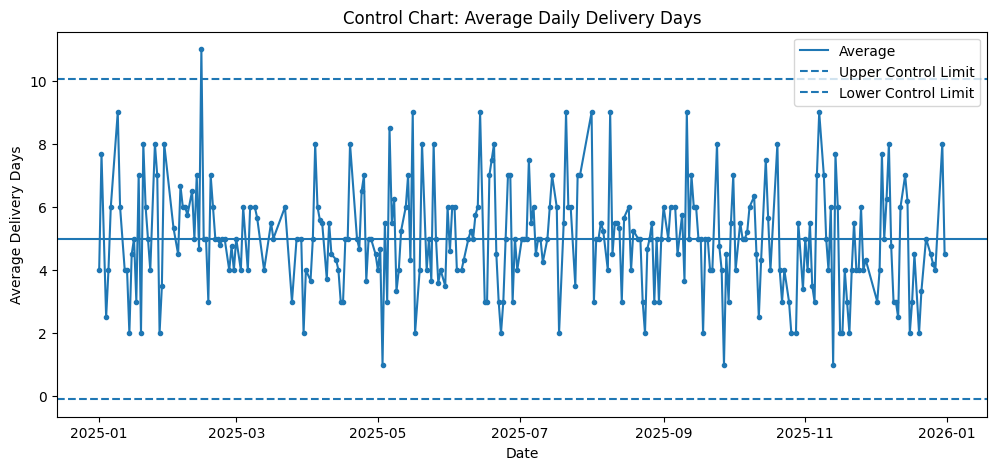

Average: 4.98
UCL: 10.06
LCL: -0.09


In [27]:
daily_delivery = df.groupby("date")["delivery_days"].mean().dropna().sort_index()

mean_val = daily_delivery.mean()
std_val = daily_delivery.std()
ucl = mean_val + 3 * std_val
lcl = mean_val - 3 * std_val

plt.figure(figsize=(12, 5))
plt.plot(daily_delivery.index, daily_delivery.values, marker="o", markersize=3)
plt.axhline(mean_val, linestyle="-", label="Average")
plt.axhline(ucl, linestyle="--", label="Upper Control Limit")
plt.axhline(lcl, linestyle="--", label="Lower Control Limit")
plt.title("Control Chart: Average Daily Delivery Days")
plt.xlabel("Date")
plt.ylabel("Average Delivery Days")
plt.legend()
plt.show()

print("Average:", round(mean_val, 2))
print("UCL:", round(ucl, 2))
print("LCL:", round(lcl, 2))

# 28. Cumulative Line Chart

## Purpose
A cumulative line chart shows accumulated progress.

## Best for
- Cumulative revenue
- Project progress
- Total users acquired
- Total cases completed

## Decision from this chart
- Check whether target is being reached
- Forecast if current pace continues
- Identify slowdown periods

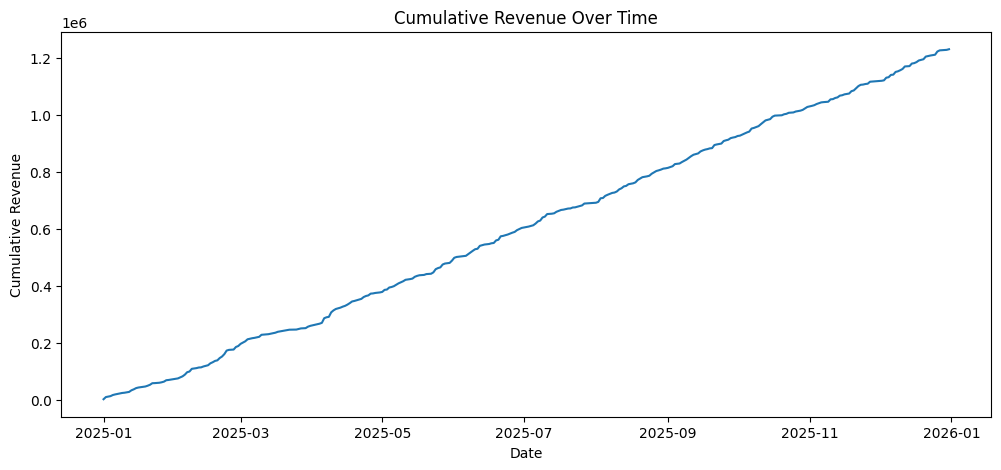

In [28]:
cumulative_revenue = daily_revenue.cumsum()

plt.figure(figsize=(12, 5))
plt.plot(cumulative_revenue.index, cumulative_revenue.values)
plt.title("Cumulative Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Revenue")
plt.show()

# 29. Error Bar Chart

## Purpose
An error bar chart shows uncertainty or variation around an average.

## Best for
- Average satisfaction by region
- Average marks by department
- Average delivery time by courier

## How to read
- Dot/bar = average
- Error bar = uncertainty/spread
- Large error bar = unstable/inconsistent

## Decision from this chart
- Avoid decisions based only on average
- Prefer categories with high average and low uncertainty
- Investigate inconsistent groups

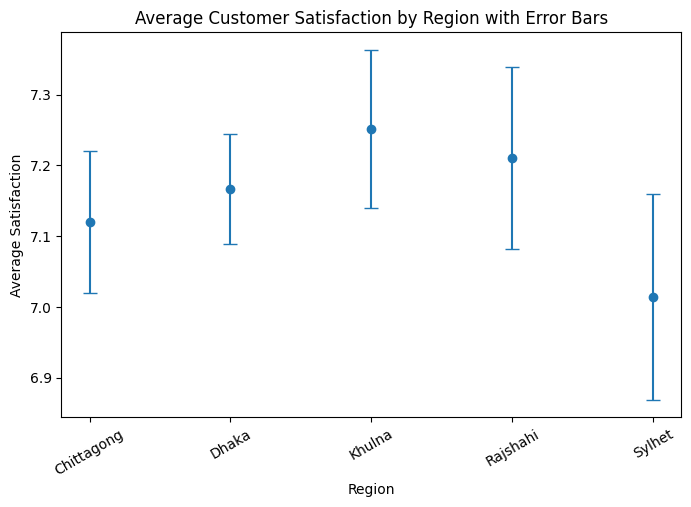

,mean,std,count,sem
region,,,,
Chittagong,7.120155,1.133880,129,0.099833
Dhaka,7.166825,1.132901,211,0.077992
Khulna,7.251852,1.007734,81,0.111970
Rajshahi,7.210345,1.197578,87,0.128394
Sylhet,7.014286,1.332101,84,0.145344


In [29]:
satisfaction_summary = df.groupby("region")["customer_satisfaction"].agg(["mean", "std", "count"]).dropna()
satisfaction_summary["sem"] = satisfaction_summary["std"] / np.sqrt(satisfaction_summary["count"])

plt.figure(figsize=(8, 5))
plt.errorbar(
    satisfaction_summary.index,
    satisfaction_summary["mean"],
    yerr=satisfaction_summary["sem"],
    fmt="o",
    capsize=5
)
plt.title("Average Customer Satisfaction by Region with Error Bars")
plt.xlabel("Region")
plt.ylabel("Average Satisfaction")
plt.xticks(rotation=30)
plt.show()

satisfaction_summary

# 30. Distribution Comparison Using Multiple Histograms

## Purpose
This compares distributions between groups.

## Best for
- Profit distribution online vs retail
- Delivery days by channel
- Marks distribution by section

## Decision from this chart
- See which group has better/worse spread
- Detect if one group has more extreme cases
- Compare consistency, not just average

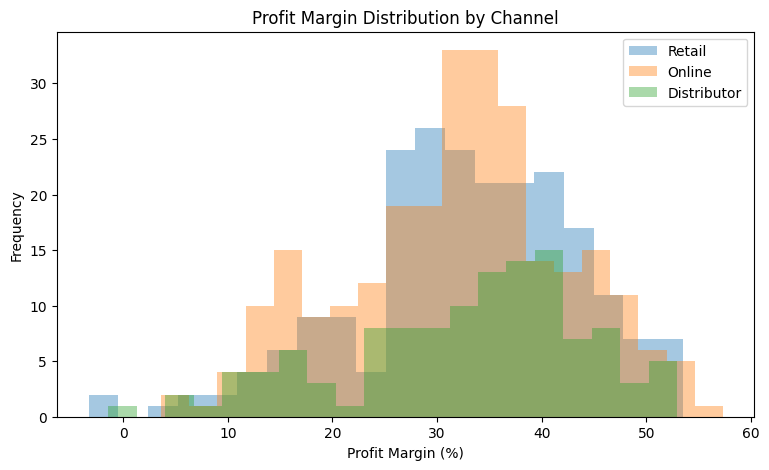

In [30]:
plt.figure(figsize=(9, 5))

for channel in df["channel"].unique():
    subset = df.loc[df["channel"] == channel, "profit_margin_pct"].dropna()
    plt.hist(subset, bins=20, alpha=0.4, label=channel)

plt.title("Profit Margin Distribution by Channel")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 31. Treemap Concept

## Purpose
A treemap shows hierarchical part-to-whole composition using rectangles.

## Best for
- Product category → subcategory revenue
- Company division → department cost
- Country → city sales

## Decision from this chart
- See dominant category quickly
- Understand hierarchy
- Identify small categories that may not matter much

## Python Note
Treemaps usually require libraries like `squarify` or `plotly`.  
In this notebook, we focus on core `matplotlib`, so we explain the concept instead of requiring extra installation.

# 32. Geographic Map Concept

## Purpose
A map shows location-based patterns.

## Best for
- Sales by district
- Disease cases by region
- Delivery delay by city
- Store performance by location

## Decision from this chart
- Choose expansion location
- Find high-risk area
- Allocate local resources
- Detect regional inequality

## Warning
Maps are powerful but can mislead if population size is ignored.  
Example: Dhaka may have more sales because it has more people, not because performance is better.

# 33. Radar / Spider Chart Concept

## Purpose
A radar chart compares multiple metrics for a few items.

## Best for
- Skill comparison
- Product feature comparison
- Player performance
- Department scorecard

## Decision from this chart
- See strength and weakness profile
- Compare balanced vs unbalanced performance

## Warning
Radar charts become confusing with too many categories or too many items.

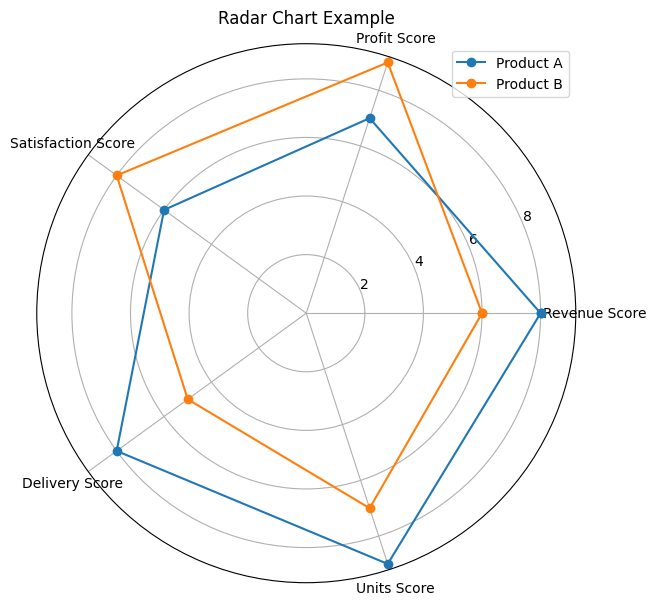

In [31]:
# Example radar chart: product score comparison
metrics = ["Revenue Score", "Profit Score", "Satisfaction Score", "Delivery Score", "Units Score"]
product_a = [8, 7, 6, 8, 9]
product_b = [6, 9, 8, 5, 7]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
product_a += product_a[:1]
product_b += product_b[:1]
angles += angles[:1]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, product_a, marker="o", label="Product A")
ax.plot(angles, product_b, marker="o", label="Product B")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title("Radar Chart Example")
ax.legend()
plt.show()

# 34. Decision Rules by Chart Type

| Chart | What You Look For | Possible Decision |
|---|---|---|
| Bar chart | Highest/lowest category | Allocate budget, investigate low performers |
| Line chart | Growth, decline, seasonality | Forecast, plan inventory, evaluate campaigns |
| Histogram | Shape, skewness, common range | Set realistic targets, detect unusual distribution |
| Boxplot | Median, spread, outliers | Investigate outliers, compare consistency |
| Scatter plot | Relationship, clusters, outliers | Test drivers, segment customers, detect risk |
| Heatmap | Strong/weak combinations | Target specific product-region combinations |
| Pie/donut | Share of total | Communicate composition, identify dominant share |
| Pareto | Top contributors | Focus on high-impact categories |
| Funnel | Stage drop-off | Fix conversion bottleneck |
| Control chart | Abnormal variation | Investigate process instability |
| Error bar | Uncertainty around average | Avoid risky decisions from unstable averages |
| Bubble chart | Relationship with size | Prioritize big and profitable segments |

# 35. How to Convert Visualization into Decision

Use this formula:

## Decision Formula

**Observation → Insight → Business Meaning → Action → Measurement**

Example:

### Observation
Online channel has high revenue but low profit margin.

### Insight
Online sales may depend heavily on discounts.

### Business Meaning
The company is selling more but earning less per sale.

### Action
Reduce discount or apply discount only to high-margin products.

### Measurement
Track profit margin and conversion rate after the change.

# 36. Example: Full Decision Analysis

Question: **Should we increase discount?**

We will check:
1. Discount vs revenue
2. Discount vs profit margin
3. Average profit margin by discount level

,discount_pct,avg_revenue,avg_profit,avg_margin,count
0,0.0,2267.197901,879.134732,38.960718,181
1,5.0,2162.603563,742.266013,34.956220,127
2,10.0,2020.710024,660.625511,31.950000,125
3,15.0,1789.690099,473.390353,26.708026,76
4,20.0,1726.867556,375.438253,21.808889,54
5,25.0,1514.207411,254.069529,15.375714,28


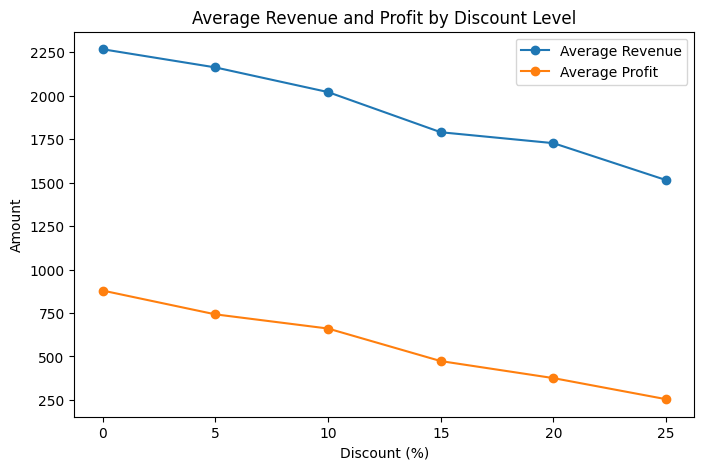

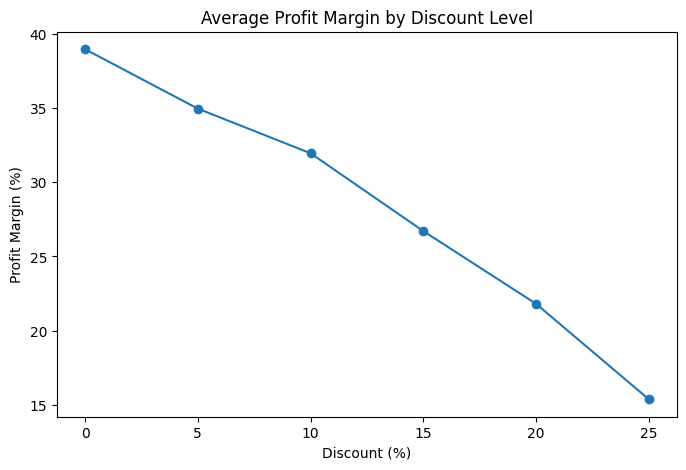

In [32]:
discount_analysis = df.groupby("discount_pct").agg(
    avg_revenue=("revenue", "mean"),
    avg_profit=("profit", "mean"),
    avg_margin=("profit_margin_pct", "mean"),
    count=("profit_margin_pct", "count")
).reset_index()

display(discount_analysis)

plt.figure(figsize=(8, 5))
plt.plot(discount_analysis["discount_pct"], discount_analysis["avg_revenue"], marker="o", label="Average Revenue")
plt.plot(discount_analysis["discount_pct"], discount_analysis["avg_profit"], marker="o", label="Average Profit")
plt.title("Average Revenue and Profit by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Amount")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(discount_analysis["discount_pct"], discount_analysis["avg_margin"], marker="o")
plt.title("Average Profit Margin by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.show()

### Decision Template

Write your decision like this:

> Discount should not be increased blindly. If revenue increases but profit margin decreases, we should apply discount only to selected products or selected customer groups. The final decision should be tested with profit margin, conversion rate, and repeat purchase rate.

# 37. Common Visualization Mistakes

## Mistake 1: Using pie chart for too many categories
Better: use bar chart.

## Mistake 2: Reading correlation as causation
Correlation means two variables move together. It does not prove one causes another.

## Mistake 3: Ignoring sample size
A category with only 3 rows may show high average by chance.

## Mistake 4: Using wrong axis scale
Changing axis scale can exaggerate small differences.

## Mistake 5: Looking only at average
Average hides outliers and distribution.

## Mistake 6: Ignoring missing values
Missing values can change the story.

## Mistake 7: Making decision from one chart only
Use multiple charts before final decision.

# 38. Final Checklist Before Taking a Decision

Before taking a decision from visualization, ask:

1. Is the chart answering the right question?
2. Is the data clean?
3. Are there missing values?
4. Is sample size enough?
5. Are there outliers?
6. Is the pattern consistent?
7. Can there be another explanation?
8. Did I compare revenue with profit?
9. Did I check trend over time?
10. What action will I take?
11. How will I measure whether the action worked?

> A good analyst does not only describe the chart.  
> A good analyst explains what to do next.

# 39. Practice Exercises

Try to answer these using the dataset:

1. Which region has the highest revenue?
2. Which product has the highest profit margin?
3. Which channel has high revenue but low profit?
4. Does higher discount increase revenue?
5. Does higher discount reduce profit margin?
6. Which region has the slowest delivery?
7. Which product-region combination should receive more marketing?
8. Which month has the highest revenue?
9. Are there abnormal delivery days?
10. Which chart would you use to present revenue share to management?

In [33]:
# Your practice space

# Example:
# df.groupby("region")["revenue"].sum().sort_values(ascending=False)

# 40. Mini Cheat Sheet

| Goal | Use This Chart |
|---|---|
| Compare categories | Bar chart |
| Rank items | Horizontal bar |
| Trend over time | Line chart |
| Smooth noisy trend | Rolling average |
| Show total over time | Area chart |
| Show distribution | Histogram |
| Show outliers | Boxplot |
| Compare distribution | Violin plot |
| Relationship | Scatter plot |
| Relationship + size | Bubble chart |
| Many relationships | Pair plot |
| Correlation | Heatmap |
| Share of total | Pie/donut |
| Contribution priority | Pareto |
| Start-to-end change | Waterfall |
| Drop-off process | Funnel |
| Process stability | Control chart |
| Uncertainty | Error bar |
| Two-category intensity | Pivot heatmap |